# Variational Autoencoder: Basics

## Real-World Scenario: Learning a Latent Space of Chromatin Accessibility

**From PML-2 Chapter 21.2**

In a typical scATAC-seq experiment, each cell is summarized as a **binary vector** over many genomic regions: each entry is `1` if that region was accessible (open chromatin) in that cell and `0` otherwise. Cells from the same cell type tend to have similar accessibility patterns, but the data is high-dimensional, sparse, and noisy.

We want a **generative model** that:
- compresses each cell's $D$-dimensional binary accessibility vector to a low-dimensional latent code $\mathbf{z}$ where cell types cluster meaningfully,
- can also **decode** any latent code back to a plausible accessibility pattern, so we can sample fresh "synthetic cells" by drawing from the prior.

That is exactly what the **variational autoencoder (VAE)** of PML-2 §21.2 provides:

$$\mathbf{z} \sim p_{\boldsymbol{\theta}}(\mathbf{z}), \qquad \mathbf{x}\mid \mathbf{z} \sim \mathrm{Expfam}(\mathbf{x}\mid d_{\boldsymbol{\theta}}(\mathbf{z})).$$

In our setup the prior is a unit Gaussian, the likelihood is a product of Bernoullis (one per region), and a neural-network **encoder** is trained jointly with the decoder to approximate the intractable posterior $p_{\boldsymbol{\theta}}(\mathbf{z}\mid \mathbf{x})$. We follow **Algorithm 21.1** directly: a full-covariance Gaussian posterior plus a Bernoulli decoder.


In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

## Key Formulas from PML-2 §21.2

### Generative model (Eq. 21.4-21.5)
$$p_{\boldsymbol{\theta}}(\mathbf{z}, \mathbf{x}) = p_{\boldsymbol{\theta}}(\mathbf{z})\, p_{\boldsymbol{\theta}}(\mathbf{x}\mid \mathbf{z}), \qquad p_{\boldsymbol{\theta}}(\mathbf{x}\mid \mathbf{z}) = \prod_{d=1}^{D} \mathrm{Ber}\!\left(x_d \mid \sigma(d_{\boldsymbol{\theta}}(\mathbf{z}))_d\right)$$

with a Gaussian prior $p_{\boldsymbol{\theta}}(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$ and a neural-network **decoder** $d_{\boldsymbol{\theta}}$ that produces logits per region.

### Recognition / inference model (Eq. 21.6-21.8)
$$q_{\boldsymbol{\phi}}(\mathbf{z}\mid \mathbf{x}) = \mathcal{N}\!\left(\mathbf{z}\mid \boldsymbol{\mu}, \boldsymbol{\Sigma}\right), \qquad (\boldsymbol{\mu}, \boldsymbol{\ell}, \mathbf{L}') = e_{\boldsymbol{\phi}}(\mathbf{x}).$$

A neural-network **encoder** $e_{\boldsymbol{\phi}}$ maps each input $\mathbf{x}$ to the parameters of a Gaussian over the latent. We use a **full-covariance** Gaussian (Algorithm 21.1), parameterized by a Cholesky factor $\mathbf{L}$ built from $\boldsymbol{\sigma} = \exp(\boldsymbol{\ell})$ on the diagonal and $\mathbf{L}'$ below the diagonal.

### Single-sample ELBO from Algorithm 21.1
$$\mathcal{L} = \underbrace{\sum_d \left[x_d \log p_d + (1-x_d)\log(1-p_d)\right]}_{\log p_{\boldsymbol{\theta}}(\mathbf{x}\mid \mathbf{z})}\; +\; \underbrace{\sum_k\left[-\tfrac{1}{2}z_k^2 - \tfrac{1}{2}\log 2\pi\right]}_{\log p_{\boldsymbol{\theta}}(\mathbf{z})}\; -\; \underbrace{\sum_k\left[-\tfrac{1}{2}\epsilon_k^2 - \tfrac{1}{2}\log 2\pi - \log\sigma_k\right]}_{\log q_{\boldsymbol{\phi}}(\mathbf{z}\mid \mathbf{x})}$$

The book writes this in three lines:

| symbol | content | comes from |
|---|---|---|
| $\mathcal{L}_{\log q\mathbf{z}}$ | $-\sum_k\left[\tfrac{1}{2}\epsilon_k^2 + \tfrac{1}{2}\log 2\pi + \log\sigma_k\right]$ | $q_{\boldsymbol{\phi}}(\mathbf{z}\mid \mathbf{x})$ |
| $\mathcal{L}_{\log p\mathbf{z}}$ | $-\sum_k\left[\tfrac{1}{2}z_k^2 + \tfrac{1}{2}\log 2\pi\right]$ | $p_{\boldsymbol{\theta}}(\mathbf{z})$ |
| $\mathcal{L}_{\log p\mathbf{x}}$ | $-\sum_d\left[x_d\log p_d + (1-x_d)\log(1-p_d)\right]$ | $p_{\boldsymbol{\theta}}(\mathbf{x}\mid \mathbf{z})$ |

with $\mathcal{L} = \mathcal{L}_{\log p\mathbf{x}} + \mathcal{L}_{\log p\mathbf{z}} - \mathcal{L}_{\log q\mathbf{z}}$ (the book minimizes this loss — note its sign convention puts the negative log-likelihood as positive).

## What the VAE actually does

Read §21.2.1 carefully and the story is:

1. **Generative direction (decoder).** A latent $\mathbf{z}$ is drawn from a *fixed* simple prior $\mathcal{N}(\mathbf{0},\mathbf{I})$, then a neural network $d_{\boldsymbol{\theta}}$ turns it into the parameters of an observation distribution. For binary data, those parameters are per-pixel/per-region Bernoulli probabilities $\sigma(d_{\boldsymbol{\theta}}(\mathbf{z}))$.
2. **Inverse direction (encoder).** Given an observation $\mathbf{x}$, computing the true posterior $p_{\boldsymbol{\theta}}(\mathbf{z}\mid \mathbf{x})$ would require the intractable marginal $p_{\boldsymbol{\theta}}(\mathbf{x}) = \int p_{\boldsymbol{\theta}}(\mathbf{x}\mid \mathbf{z})\,p(\mathbf{z})\,d\mathbf{z}$. So we train a second neural network $e_{\boldsymbol{\phi}}$ to *output the parameters of an approximate posterior* $q_{\boldsymbol{\phi}}(\mathbf{z}\mid \mathbf{x})$ — here a Gaussian whose mean, log-std, and Cholesky off-diagonals depend on $\mathbf{x}$.
3. **Joint training.** Both networks are trained at the same time to maximize a single objective: the **ELBO** $\mathbb{E}_{q_{\boldsymbol{\phi}}(\mathbf{z}\mid \mathbf{x})}[\log p_{\boldsymbol{\theta}}(\mathbf{x}\mid \mathbf{z})] - D_{\mathrm{KL}}\!\left(q_{\boldsymbol{\phi}}(\mathbf{z}\mid \mathbf{x})\,\|\,p(\mathbf{z})\right)$. The reparameterization trick turns the sample inside the expectation into a differentiable function of $\boldsymbol{\phi}$.

This is **amortized inference**: a single encoder network, trained once, gives an approximate posterior for *any* new input — no per-datapoint optimization at test time.

### Mapping the book's symbols to this notebook

| book symbol | this notebook | meaning |
|---|---|---|
| $\mathbf{x}$ | binary vector of region accessibilities for one cell | the observation |
| $\mathbf{z}$ | $K{=}2$-dim latent code per cell | what we infer (and use for visualization) |
| $\boldsymbol{\theta}$ | weights of the decoder MLP | generative parameters |
| $\boldsymbol{\phi}$ | weights of the encoder MLP | inference / recognition parameters |
| $D$ | $100$ | number of accessibility features |
| $K$ | $2$ | latent dimensionality |
| $p_d = \sigma(d_{\boldsymbol{\theta}}(\mathbf{z}))_d$ | Bernoulli probability for region $d$ | decoder output |

## Step 1: Simulate a binary scATAC-seq Dataset

We pretend we measured chromatin accessibility at $D=100$ genomic regions in $N=4000$ single cells, drawn from $K_{\text{type}}=4$ cell types (e.g., stem, neuron, muscle, immune).

For each cell type $t$, we sample a "typical" accessibility profile $\boldsymbol{\pi}_t \in [0,1]^D$ — most regions are off, a small number are strongly on. Cell $n$ of type $t$ then has $x_{n,d} \sim \mathrm{Ber}(\pi_{t,d})$. This is a faithful caricature of the real data: cell types differ mostly in *which subset* of regions tend to be accessible.

The VAE does **not** see the cell-type labels during training. We only use them at evaluation time to check whether the learned latent space separates types.

X shape: (4000, 100), dtype: float32
Mean fraction of accessible regions per cell: 0.194
Cells per type: [ 991  998  975 1036]


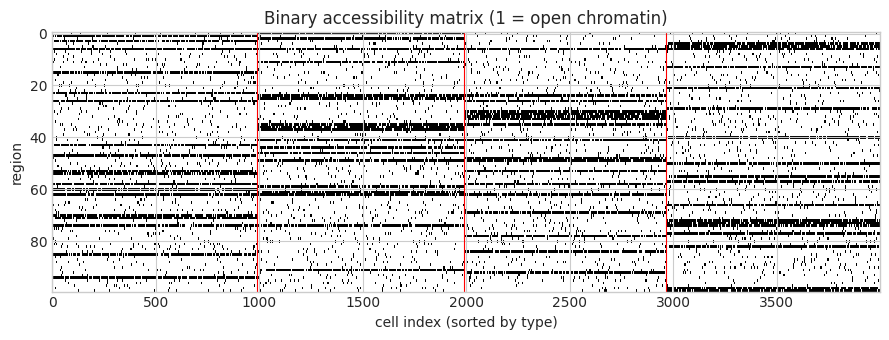

In [2]:
# --- Synthetic scATAC-seq dataset ---
D = 100                  # number of genomic regions
N = 4000                 # number of cells
K_types = 4              # number of cell types (hidden from the VAE)

rng = np.random.default_rng(0)

# For each type, draw a sparse accessibility profile.
def make_profile(d, n_open=18, p_on=0.85, p_off=0.05):
    pi = np.full(d, p_off)
    open_idx = rng.choice(d, size=n_open, replace=False)
    pi[open_idx] = p_on
    return pi

type_profiles = np.stack([make_profile(D) for _ in range(K_types)])  # (K, D)

# Sample cells uniformly across types.
labels = rng.integers(0, K_types, size=N)
X = (rng.random((N, D)) < type_profiles[labels]).astype(np.float32)

print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"Mean fraction of accessible regions per cell: {X.mean():.3f}")
print(f"Cells per type: {np.bincount(labels)}")

# Quick visual of the data matrix sorted by type
order = np.argsort(labels)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.imshow(X[order].T, aspect='auto', cmap='Greys', interpolation='nearest')
for t in range(1, K_types):
    ax.axvline(np.searchsorted(labels[order], t), color='red', linewidth=0.8)
ax.set_xlabel('cell index (sorted by type)')
ax.set_ylabel('region')
ax.set_title('Binary accessibility matrix (1 = open chromatin)')
plt.tight_layout()
plt.show()

The vertical red lines mark the boundaries between cell types. Within each block you can see the type-specific bands of consistently-on regions — that's the structure the VAE will discover, without ever being told it exists.

## Step 2: The Encoder $e_{\boldsymbol{\phi}}(\mathbf{x})$

Per Algorithm 21.1, the encoder reads $\mathbf{x}$ and outputs:
- $\boldsymbol{\mu} \in \mathbb{R}^K$ — the posterior mean,
- $\boldsymbol{\ell} = \log\boldsymbol{\sigma} \in \mathbb{R}^K$ — log-std on the diagonal of the Cholesky factor,
- $\mathbf{L}' \in \mathbb{R}^{K\times K}$ — raw matrix from which we read the strict-lower-triangular entries.

The full Cholesky factor is then
$$\mathbf{L} = \mathrm{tril}(\mathbf{L}', -1) + \mathrm{diag}(\boldsymbol{\sigma}),$$
so $\boldsymbol{\Sigma} = \mathbf{L}\mathbf{L}^\top$ is a valid covariance matrix with the right diagonal scale.

For our small problem one hidden layer with $H=64$ units is plenty.

In [3]:
K = 2          # latent dim
H = 64         # hidden width

class Encoder(nn.Module):
    # e_phi(x) -> (mu, log_sigma, L_offdiag)
    def __init__(self, d_in=D, k=K, hidden=H):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(d_in, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.head_mu        = nn.Linear(hidden, k)
        self.head_log_sigma = nn.Linear(hidden, k)
        # raw lower-triangular off-diagonal entries (k*(k-1)/2 of them)
        self.k = k
        self.head_loff      = nn.Linear(hidden, k * (k - 1) // 2)

    def forward(self, x):
        h = self.body(x)
        mu = self.head_mu(h)
        log_sigma = self.head_log_sigma(h).clamp(-7.0, 7.0)
        loff_flat = self.head_loff(h)                       # (B, k*(k-1)/2)
        return mu, log_sigma, loff_flat

    def cholesky(self, log_sigma, loff_flat):
        # Build (B, k, k) lower-triangular Cholesky factors.
        B = log_sigma.shape[0]
        L = torch.zeros(B, self.k, self.k, device=log_sigma.device)
        # strict-lower-triangle indices
        i, j = torch.tril_indices(self.k, self.k, offset=-1)
        L[:, i, j] = loff_flat
        L[:, range(self.k), range(self.k)] = log_sigma.exp()
        return L

## Step 3: The Decoder $d_{\boldsymbol{\theta}}(\mathbf{z})$

The decoder takes a latent $\mathbf{z}$ and outputs $D$ Bernoulli **logits** (we apply $\sigma$ inside the Bernoulli log-likelihood, not on the output, for numerical stability). With a Bernoulli likelihood, the decoder is the "generative model" itself — sample a $\mathbf{z}$ from the prior, push through the decoder, then sample binary outputs and you have a brand-new synthetic cell.

In [4]:
class Decoder(nn.Module):
    # d_theta(z) -> logits over D Bernoullis
    def __init__(self, k=K, d_out=D, hidden=H):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(k, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, d_out),                       # logits
        )

    def forward(self, z):
        return self.net(z)

## Step 4: One Step of Algorithm 21.1

Each gradient step does, for a minibatch of cells $\mathbf{x}$:

1. encoder: $(\boldsymbol{\mu}, \boldsymbol{\ell}, \mathbf{L}') = e_{\boldsymbol{\phi}}(\mathbf{x})$;
2. build the Cholesky $\mathbf{L}$;
3. sample $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and form $\mathbf{z} = \mathbf{L}\boldsymbol{\epsilon} + \boldsymbol{\mu}$ — this is the **reparameterization trick**, the only reason we can back-propagate through the sampling;
4. decoder logits: $\mathbf{p} = \sigma(d_{\boldsymbol{\theta}}(\mathbf{z}))$;
5. plug everything into the three closed-form sums above.

For numerical stability we keep the Bernoulli term in logit form via `binary_cross_entropy_with_logits` — mathematically identical to $-\sum_d[x_d\log p_d + (1-x_d)\log(1-p_d)]$.

### A subtle but important detail: $\log q_{\boldsymbol{\phi}}(\mathbf{z}\mid \mathbf{x})$ for full covariance

In the **diagonal** case, $\boldsymbol{\sigma}\odot \boldsymbol{\epsilon}$ has no cross-coupling, so $\log q = -\sum_k[\tfrac{1}{2}\epsilon_k^2 + \tfrac{1}{2}\log 2\pi + \log\sigma_k]$, exactly as Algorithm 21.1 writes it (line 10).

For a **full-covariance** Cholesky, however, the change-of-variables Jacobian is $|\det \mathbf{L}| = \prod_k L_{kk} = \prod_k \sigma_k$ (still only the diagonal — that's the magic of triangular matrices), but $\boldsymbol{\epsilon} = \mathbf{L}^{-1}(\mathbf{z} - \boldsymbol{\mu})$ no longer factors elementwise. The clean way is to evaluate $\log q$ via `MultivariateNormal(scale_tril=L).log_prob(z)`. Algorithmically, applying line 10 verbatim with a full-cov sampler is a small approximation — `MultivariateNormal.log_prob` is exact, so we use it.

In [5]:
def vae_loss(x, encoder, decoder):
    # Negative ELBO averaged over the batch. Returns total loss plus E and R parts.
    mu, log_sigma, loff = encoder(x)
    L = encoder.cholesky(log_sigma, loff)                   # (B, K, K)

    # reparameterized sample z = L @ eps + mu
    eps = torch.randn_like(mu)
    z = (L @ eps.unsqueeze(-1)).squeeze(-1) + mu            # (B, K)

    # decoder logits and Bernoulli reconstruction term
    logits = decoder(z)                                     # (B, D)
    log_p_x_given_z = -F.binary_cross_entropy_with_logits(
        logits, x, reduction='none'
    ).sum(dim=-1)                                           # (B,)

    # log p(z) under N(0, I)
    log_p_z = -0.5 * (z ** 2).sum(-1) - 0.5 * K * np.log(2 * np.pi)

    # log q(z|x) — full Gaussian log-density via the Cholesky factor
    q_dist = torch.distributions.MultivariateNormal(loc=mu, scale_tril=L)
    log_q_z = q_dist.log_prob(z)                            # (B,)

    elbo = log_p_x_given_z + log_p_z - log_q_z              # (B,)
    loss = -elbo.mean()

    # report the two ELBO components separately
    reconstruction = -log_p_x_given_z.mean()
    kl_term = (log_q_z - log_p_z).mean()
    return loss, reconstruction.detach(), kl_term.detach()

## Step 5: Train

Adam over the encoder/decoder parameters jointly. We minibatch 4000 cells in groups of 128 for 60 epochs.

In [6]:
X_t = torch.tensor(X)                              # (N, D)

encoder = Encoder()
decoder = Decoder()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=2e-3)

batch_size = 128
epochs = 60
history = {'loss': [], 'recon': [], 'kl': []}

for ep in range(epochs):
    perm = torch.randperm(N)
    epoch_loss = epoch_recon = epoch_kl = 0.0
    n_batches = 0
    for start in range(0, N, batch_size):
        idx = perm[start:start + batch_size]
        x_batch = X_t[idx]

        opt.zero_grad()
        loss, recon, kl = vae_loss(x_batch, encoder, decoder)
        loss.backward()
        opt.step()

        epoch_loss  += loss.item()
        epoch_recon += recon.item()
        epoch_kl    += kl.item()
        n_batches   += 1

    history['loss'].append(epoch_loss / n_batches)
    history['recon'].append(epoch_recon / n_batches)
    history['kl'].append(epoch_kl / n_batches)

    if (ep + 1) % 10 == 0:
        print(f"epoch {ep+1:>3d}  -ELBO = {history['loss'][-1]:.2f}  "
              f"recon = {history['recon'][-1]:.2f}  KL = {history['kl'][-1]:.3f}")

epoch  10  -ELBO = 26.30  recon = 23.93  KL = 2.362


epoch  20  -ELBO = 26.27  recon = 23.93  KL = 2.348


epoch  30  -ELBO = 25.96  recon = 23.70  KL = 2.264


epoch  40  -ELBO = 25.93  recon = 23.71  KL = 2.222


epoch  50  -ELBO = 25.93  recon = 23.69  KL = 2.244


epoch  60  -ELBO = 25.87  recon = 23.68  KL = 2.196


## Step 6: Training Curves

The three traces are the negative ELBO (what we minimize), the reconstruction term $-\log p_{\boldsymbol{\theta}}(\mathbf{x}\mid \mathbf{z})$, and the KL term $D_{\mathrm{KL}}(q_{\boldsymbol{\phi}}(\mathbf{z}\mid \mathbf{x})\,\|\,p(\mathbf{z}))$ (estimated as $\mathbb{E}_q[\log q - \log p]$).

A working VAE has both terms decreasing initially; if the KL collapses to ~0 the encoder has learned to ignore $\mathbf{x}$ (\"posterior collapse\"), and if the reconstruction stays high the decoder is too weak. Here neither pathology should appear.

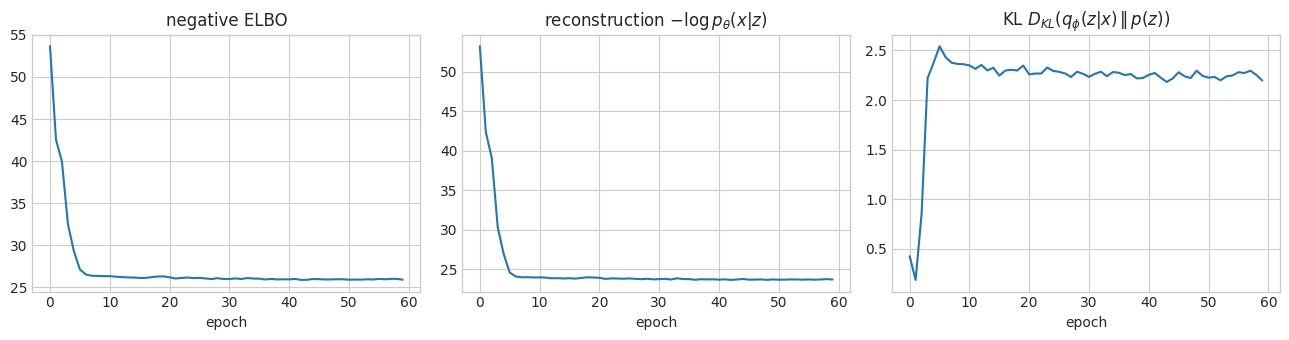

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
ax[0].plot(history['loss']);  ax[0].set_title('negative ELBO')
ax[1].plot(history['recon']); ax[1].set_title(r'reconstruction $-\log p_\theta(x|z)$')
ax[2].plot(history['kl']);    ax[2].set_title(r'KL $D_{KL}(q_\phi(z|x)\,\|\,p(z))$')
for a in ax:
    a.set_xlabel('epoch')
plt.tight_layout()
plt.show()

## Step 7: Look at the Latent Space

For every cell, encode it and take the **posterior mean** $\boldsymbol{\mu}_{\boldsymbol{\phi}}(\mathbf{x})$ as its 2D coordinate. Color by the true cell-type label (which the VAE never saw).

If the model has learned anything useful, the four types should form distinct clusters.

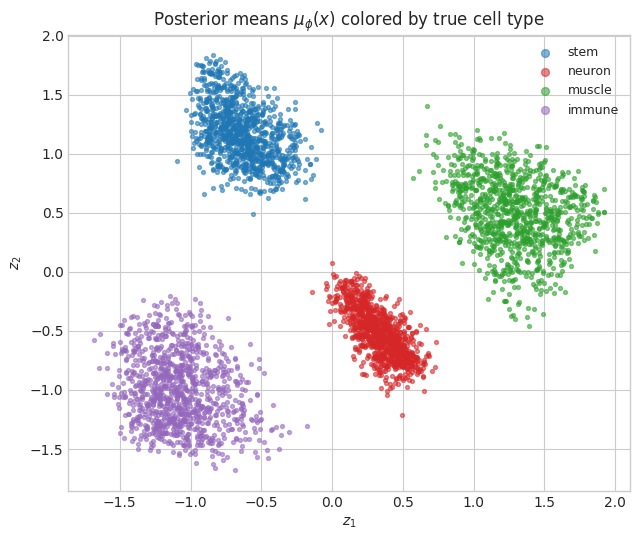

Encoder per-cell posterior std (mean across cells): [0.355 0.391]


In [8]:
encoder.eval()
with torch.no_grad():
    mu_all, log_sigma_all, _ = encoder(X_t)
    Z = mu_all.numpy()
    sigma_all = log_sigma_all.exp().numpy()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
palette = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']
type_names = ['stem', 'neuron', 'muscle', 'immune']
for t in range(K_types):
    pts = Z[labels == t]
    ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.55,
               color=palette[t], label=type_names[t])
ax.set_xlabel(r'$z_1$')
ax.set_ylabel(r'$z_2$')
ax.set_title(r'Posterior means $\mu_\phi(x)$ colored by true cell type')
ax.legend(loc='best', fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

print('Encoder per-cell posterior std (mean across cells):',
      sigma_all.mean(axis=0).round(3))

The four cell types cluster cleanly — the VAE has discovered the latent structure by reconstruction alone. The reported posterior stds tell us how *tight* the encoder is around each cell's mean. Values much smaller than 1 mean the encoder is confident; values near 1 mean the posterior has not moved far from the prior.

## Step 8: Reconstructions

For a few random cells we compare:
- **input** $\mathbf{x}$,
- **decoder probabilities** $\mathbf{p} = \sigma(d_{\boldsymbol{\theta}}(\boldsymbol{\mu}_{\boldsymbol{\phi}}(\mathbf{x})))$ (gray = uncertain, black = on),
- **a binary sample** drawn from those Bernoullis.

A good VAE matches the prominent on-regions of the input.

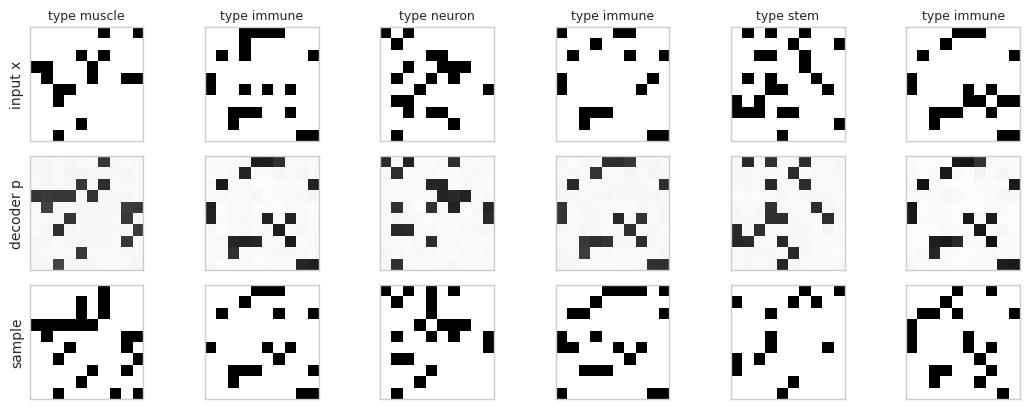

In [9]:
sample_idx = rng.choice(N, size=6, replace=False)
with torch.no_grad():
    mu_s, _, _ = encoder(X_t[sample_idx])
    p_s = torch.sigmoid(decoder(mu_s)).numpy()
    x_s = X_t[sample_idx].numpy()
    samp = (np.random.random(p_s.shape) < p_s).astype(np.float32)

fig, axes = plt.subplots(3, 6, figsize=(11, 4.2))
row_labels = ['input x', 'decoder p', 'sample']
for col, idx in enumerate(sample_idx):
    for row, mat in enumerate([x_s[col], p_s[col], samp[col]]):
        ax = axes[row, col]
        ax.imshow(mat.reshape(10, 10), cmap='Greys', vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=10)
        if row == 0:
            ax.set_title(f'type {type_names[labels[idx]]}', fontsize=9)
plt.tight_layout()
plt.show()

## Step 9: Generate Brand-New \"Cells\" by Sampling the Prior

Because the VAE is a real generative model, we can sample fresh data without ever touching the dataset:
1. draw $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$,
2. push through the decoder to get region probabilities,
3. sample binary outputs.

Each generated sample should look like a plausible cell of *some* type — the prior covers the trained region of latent space.

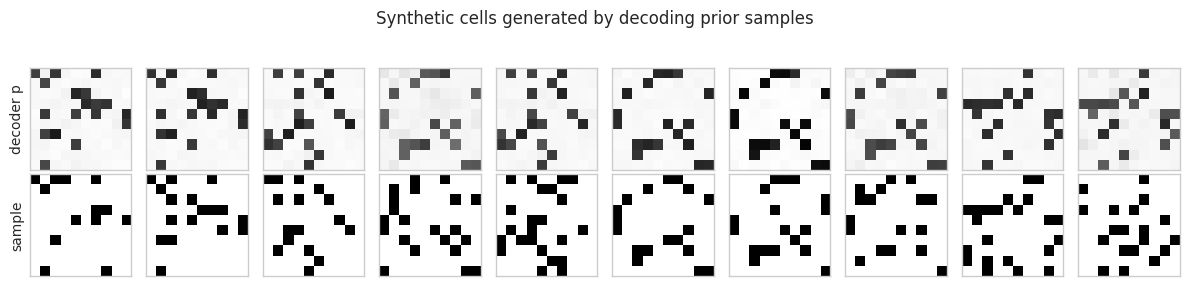

In [10]:
with torch.no_grad():
    z_prior = torch.randn(10, K)
    p_prior = torch.sigmoid(decoder(z_prior)).numpy()
    samp_prior = (np.random.random(p_prior.shape) < p_prior).astype(np.float32)

fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
for col in range(10):
    axes[0, col].imshow(p_prior[col].reshape(10, 10), cmap='Greys', vmin=0, vmax=1)
    axes[1, col].imshow(samp_prior[col].reshape(10, 10), cmap='Greys', vmin=0, vmax=1)
    for r in range(2):
        axes[r, col].set_xticks([]); axes[r, col].set_yticks([])
axes[0, 0].set_ylabel('decoder p', fontsize=10)
axes[1, 0].set_ylabel('sample',    fontsize=10)
plt.suptitle('Synthetic cells generated by decoding prior samples', y=1.02)
plt.tight_layout()
plt.show()

## Step 10: The Latent Manifold

Sweep the 2D latent on a regular grid and plot the decoder's per-cell probability map at each grid point. This is the VAE's equivalent of "what shape does each part of latent space stand for?". Patches of latent space corresponding to the cluster centers should produce distinct accessibility patterns; transitions between clusters should interpolate smoothly.

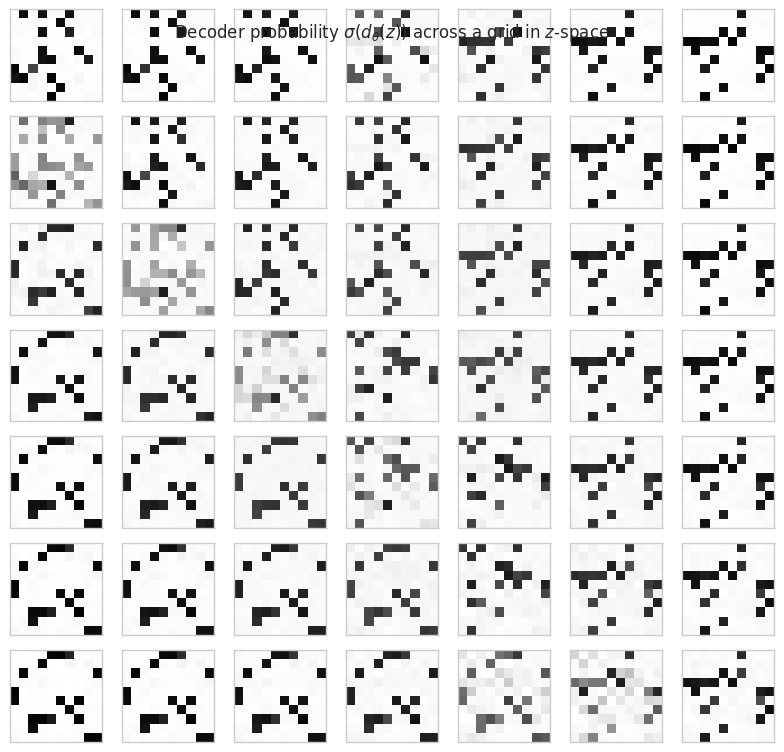

In [11]:
grid = np.linspace(-2.5, 2.5, 7)
fig, axes = plt.subplots(len(grid), len(grid), figsize=(8, 8))
with torch.no_grad():
    for i, z1 in enumerate(grid[::-1]):     # flip so y increases upward
        for j, z2 in enumerate(grid):
            z = torch.tensor([[z2, z1]], dtype=torch.float32)
            p = torch.sigmoid(decoder(z)).numpy().reshape(10, 10)
            ax = axes[i, j]
            ax.imshow(p, cmap='Greys', vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(r'Decoder probability $\sigma(d_\theta(z))$ across a grid in $z$-space',
             y=0.92)
plt.tight_layout()
plt.show()

## Summary

### What we built
A complete VAE for binary scATAC-seq-like data:
- a prior $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$ on $K=2$ latents,
- a Bernoulli decoder $p_{\boldsymbol{\theta}}(\mathbf{x}\mid \mathbf{z}) = \prod_d \mathrm{Ber}(\sigma(d_{\boldsymbol{\theta}}(\mathbf{z}))_d)$,
- a full-covariance Gaussian encoder $q_{\boldsymbol{\phi}}(\mathbf{z}\mid \mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}, \mathbf{L}\mathbf{L}^\top)$,
- trained end-to-end with the reparameterized ELBO of Algorithm 21.1.

### Key takeaways from PML-2 §21.2
1. **Amortized inference.** A single encoder network gives an approximate posterior for *any* input — no per-datapoint optimization at test time.
2. **Three terms, one objective.** Algorithm 21.1's pseudocode is literally the three log-density sums $\mathcal{L}_{\log p\mathbf{x}}$, $\mathcal{L}_{\log p\mathbf{z}}$, $\mathcal{L}_{\log q\mathbf{z}}$ combined into the ELBO.
3. **Full-covariance posterior is cheap in low dim.** The Cholesky parameterization $\mathbf{L} = \mathrm{tril}(\mathbf{L}', -1) + \mathrm{diag}(\boldsymbol{\sigma})$ adds only $K(K-1)/2$ outputs to the encoder; for high-dimensional latents you'd revert to diagonal.
4. **The decoder *is* the generative model.** Once trained, sampling $\mathbf{z}\sim p(\mathbf{z})$ and pushing through $d_{\boldsymbol{\theta}}$ gives fresh synthetic data without touching the dataset — exactly the property a deterministic autoencoder lacks.
5. **Cell-type structure emerges unsupervised.** The 2D latent separates the four cell types cleanly despite never seeing the labels — the same phenomenon that makes VAEs useful for single-cell genomics in practice (e.g., scVI).
